# Day 36 — Generation, Prompt Engineering & Citations
## Merinos Halı Sanayi A.Ş. — Endüstriyel Yapay Zekâ Staj Portfolyosu

---

> ### **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya ticari/ticari olmayan projelerde kullanılamaz.  
> İzin talepleri için: GitHub @seydivakkas  
> **Lisans Rozeti:** `https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square`

---

### **Staj Defteri Konu ve Kapsam Özeti**
* **Şekil 71:** Endüstriyel RAG'de Yanıt Üretimi, Sistem Prompt Mühendisliği (Role Persona & Context Isolation), XML Blok İzolasyonu ve Pydantic Yapılandırılmış Çıktı Mimarisi (`GeneratedAnswer` / `StructuredAnswer`).
* **Şekil 72:** Katı Alıntı Doğrulama (Groundedness / Faithfulness), Claim-Level NLI Mantığı, Citation Precision/Recall ve Tuzak/Alan Dışı Sorularda Halüsinasyon Bastırma (Adversarial Fallback Protocol).



## 1. Problem
Endüstriyel üretim hatlarında (Gaziantep Merinos tesislerinde çalışan dokuma tezgâhları, buharlı fikse üniteleri ve kalite kontrol merkezleri) operatörlerin teknik arıza anında hızlı, güvenilir ve doğrulanabilir bilgiye erişmesi gerekir.
Klasik LLM üretimleri iki temel hayati risk barındırır:
1. **Halüsinasyon (Uydurma):** Modelin gerçekte var olmayan tolerans limitleri veya güvenlik prosedürleri icat etmesi.
2. **Serbest Biçimli (Unstructured) Yanıtlar:** PLC ve SCADA arıza log sistemlerine otomatik aktarılamayan, laf kalabalığı içeren metinler.

Bu çalışmada amaç: Yalnızca getirilen kılavuz parçalarına (`<retrieved_context>`) dayanan, sayısal parametreleri ve doğrulanmış kaynak alıntılarını içeren yapılandırılmış yanıtlar (`GeneratedAnswer`) üretmek ve iddia bazında sadakati (%100 alıntı kesinliği ile) denetlemektir.



## 2. Why the Problem Matters
1. **Fiziksel Hasar ve Üretim Duruşu:** E-401 motor sıcaklığı aşımında motorun durdurulmaması veya 85°C yerine yanlış bir eşik bildirilmesi ana tahrik motorunun yanmasına ve günlerce süren hat duruşuna yol açar.
2. **Denetlenebilirlik ve Sorumluluk:** Operatör bir eylemde bulunduğunda ("Vana 3 ayarlandı", "Yavaş moda geçildi"), bu kararın hangi dokümana ve hangi maddeye dayandığı (`DOC_MERINOS_WEAVING_SOP_c004`) SCADA sisteminde alıntı olarak kayıt altına alınmalıdır.
3. **Güvenli Ret (Adversarial Robustness):** E-999 gibi sahte arıza kodlarında veya fabrika dışı sorularda model tahmin yürütmek yerine açıkça güvenli ret (fallback) vermelidir.



## 3. Engineering Concepts
* **Strict Context Isolation (Katı Bağlam İzolasyonu):** Model promptunda `<retrieved_context>` ve `<operator_query>` XML etiketleri ayrılarak sistem kurallarına katı kısıt koyulur.
* **Structured Generation (Yapılandırılmış Üretim):** Pydantic tabanlı `GeneratedAnswer` şeması ile `direct_answer`, `steps`, `parameters`, `citations` ve `safety_alert` bileşenleri deterministik olarak ayrıştırılır.
* **Claim-Level NLI Verification:** Yanıttaki her bir bağımsız iddia atomik olarak ayrıştırılır ve getirilen doküman parçası ile semantik/leksikal örtüşme puanı ($S \ge 0.50$) hesaplanarak `FAITHFUL` veya `UNSUPPORTED` kararı verilir:
$$\text{Faithfulness Rate} = \frac{\sum_{i=1}^{N} \mathbb{I}(\text{claim}_i \text{ is supported})}{N}$$
* **Citation Precision & Recall:**
$$\text{Citation Precision} = \frac{\text{Doğrulanmış Alıntılar}}{\text{Toplam Alıntılar}}, \quad \text{Citation Recall} = \frac{\text{Alıntılı İddialar}}{\text{Toplam Desteklenen İddialar}}$$



## 4. Library/API Investigation
* `pydantic.BaseModel`: SCADA entegrasyonu için tip doğrulamalı veri şemaları (`GeneratedAnswer`, `SourceCitation`).
* `re` (Düzenli İfadeler): Sayısal parametre korumalı `(?<!\d)\.(?!\d)` cümle ayrıştırma ve endüstriyel birim (`bar`, `°C`, `mm`, `Newton`, `E-\d{3}`) regex çıkarıcıları.
* `day31.mini_project.src.knowledge_manager`: BM25 ve Dense vektör indekslerini yöneten birleşik bilgi yöneticisi.
* `day32.mini_project.src.hybrid_retriever`: Hibrit arama (Dense + Sparse) motoru.



## 5. Minimal Implementation
Ortamın ve Gün 36 üretim bileşenlerinin (`PromptBuilder`, `StructuredGenerator`, `GroundednessChecker`) başlatılması:


In [1]:
import os
import sys
import json
from pathlib import Path

# Workspace kök dizinini ekleyelim
PROJECT_ROOT = Path(os.path.abspath(".."))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day31.mini_project.src.knowledge_manager import KnowledgeManager
from day32.mini_project.src.hybrid_retriever import HybridRetriever
from day36.mini_project.src.models import GeneratedAnswer, SourceCitation
from day36.mini_project.src.prompt_builder import PromptBuilder
from day36.mini_project.src.structured_generator import StructuredGenerator
from day36.mini_project.src.groundedness_checker import GroundednessChecker
from day36.mini_project.src.generation_evaluator import GenerationEvaluator
from day36.mini_project.src.visualizer import plot_generation_citation_dashboard

print("✅ Gün 36 modülleri başarıyla yüklendi.")



✅ Gün 36 modülleri başarıyla yüklendi.


In [2]:
docs_dir = str(PROJECT_ROOT / "day31" / "mini_project" / "fixtures" / "documents")
km = KnowledgeManager(documents_dir=docs_dir)
km.sync()

hybrid = HybridRetriever(
    bm25=km.bm25,
    dense=km.dense,
    chunks=km.chunks,
    default_k_rrf=60,
    default_alpha=0.5
)
chunk_lookup = {c.chunk_id: c for c in km.chunks}

prompt_builder = PromptBuilder()
generator = StructuredGenerator(prompt_builder=prompt_builder)
checker = GroundednessChecker(threshold=0.50)

print(f"✅ Üretim ve Alıntı Doğrulama sistemi hazır. İndekslenen parça sayısı: {len(chunk_lookup)}")



W0924 21:51:50.764000 1232 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Üretim ve Alıntı Doğrulama sistemi hazır. İndekslenen parça sayısı: 10


## 6. Experiment
### 6.1. E-401 Motor Sıcaklığı Arızası (Şekil 71 Doğrudan Testi)
Operatörün motor sıcaklığı arızası sorusuna sistemin yanıt üretimi:


In [3]:
query_e401 = "E-401 motor sıcaklığı arızasında operatör ne yapmalıdır?"
ret_res = hybrid.search(query_e401, method="linear", top_k=2, alpha=0.5)
retrieved_chunks = [chunk_lookup[it.chunk_id] for it in ret_res.items]

ans_e401 = generator.generate(query_e401, retrieved_chunks)

print(f"Soru: {ans_e401.query}")
print(f"Cevap: {ans_e401.answer}")
print("Önerilen adımlar:")
for idx, s in enumerate(ans_e401.steps, start=1):
    print(f"{idx}. {s}")
print("Teknik parametreler:")
for k, v in ans_e401.parameters.items():
    print(f"• {k}: {v}")
print("Kaynaklar:")
for cit in ans_e401.citations:
    print(f"• {cit.chunk_id} ({cit.section})")



Soru: E-401 motor sıcaklığı arızasında operatör ne yapmalıdır?
Cevap: E-401 motor sıcaklığı 85°C değerini aştığında motorun korunması için yük azaltılmalı ve soğutma kontrol edilmelidir.
Önerilen adımlar:
1. E-401 motor sıcaklığını operatör panelinden kontrol edin.
2. Sıcaklık 85°C üzerindeyse yükü kademeli olarak azaltın.
3. Soğutma sisteminin (fan ve hava akışı) çalıştığını kontrol edin.
4. 15 dakika içinde sıcaklık düşmezse bakım ekibine haber verin.
Teknik parametreler:
• Ekipman: E-401
• Sıcaklık limiti: 85°C
• İzleme süresi: 15 dakika
Kaynaklar:
• DOC_MERINOS_WEAVING_SOP_c004 (Bölüm 4.2 - Motor sıcaklığı ve koruma prosedürü)


### 6.2. 15 Altın Senaryoluk Kapsamlı Üretim Benchmarkı
12 geçerli teknik soru ve 3 tuzak senaryo üzerinden derlenen doğruluk ve alıntı raporu:


In [4]:
dataset_path = PROJECT_ROOT / "day36" / "mini_project" / "fixtures" / "groundedness_evaluation_dataset.json"
evaluator = GenerationEvaluator(
    knowledge_manager=km,
    hybrid_retriever=hybrid,
    generator=generator,
    checker=checker,
    top_k=3
)

report = evaluator.run_benchmark(str(dataset_path))

print(f"{'ID':<10} | {'Kategori':<20} | {'Sadakat':<8} | {'Prec.':<7} | {'Rec.':<7} | {'Güvenli Ret'}")
print("-" * 75)
for it in report.items:
    fb_str = "DOĞRU RET" if (it.is_adversarial and it.fallback_triggered) else ("NORMAL" if not it.is_adversarial else "HATA")
    print(f"{it.scenario_id:<10} | {it.category:<20} | %{it.faithfulness_rate*100:<7.0f} | %{it.citation_precision*100:<6.0f} | %{it.citation_recall*100:<6.0f} | {fb_str}")

print("-" * 75)
print(f"🏆 Ortalama Faithfulness (Sadakat)     : %{report.mean_faithfulness_rate*100:.1f}")
print(f"🏆 Ortalama Citation Precision         : %{report.mean_citation_precision*100:.1f}")
print(f"🏆 Ortalama Citation Recall            : %{report.mean_citation_recall*100:.1f}")
print(f"🏆 Tuzak/Alan Dışı Güvenli Ret Başarımı: %{report.adversarial_fallback_accuracy*100:.1f} (SIFIR HALÜSİNASYON)")



ID         | Kategori             | Sadakat  | Prec.   | Rec.    | Güvenli Ret
---------------------------------------------------------------------------
GROUND_01  | MAINTENANCE_SOP      | %0       | %100    | %0      | NORMAL
GROUND_02  | QUALITY_TOLERANCE    | %100     | %100    | %100    | NORMAL
GROUND_03  | FINISHING_PROCESS    | %100     | %100    | %100    | NORMAL
GROUND_04  | ERROR_CODE           | %100     | %100    | %100    | NORMAL
GROUND_05  | WEAVING_SPEC         | %100     | %100    | %100    | NORMAL
GROUND_06  | WEAVING_SPEC         | %80      | %100    | %80     | NORMAL
GROUND_07  | ERROR_CODE           | %100     | %100    | %100    | NORMAL
GROUND_08  | QUALITY_TOLERANCE    | %100     | %100    | %100    | NORMAL
GROUND_09  | FINISHING_PROCESS    | %100     | %100    | %100    | NORMAL
GROUND_10  | FINISHING_PROCESS    | %100     | %100    | %100    | NORMAL
GROUND_11  | MAINTENANCE_SOP      | %100     | %100    | %100    | NORMAL
GROUND_12  | QUALITY_TOLERANCE 

## 7. Visualization
Şekil 72 ile birebir uyumlu koyu temalı 4 panelli teşhis paneli:
1. Senaryo Bazlı Doğruluk ve Kaynak Kontrolü (Scatter Plot)
2. Genel Değerlendirme Metrikleri (6 KPI Kartı)
3. Kategori Bazlı Karşılaştırma (Gruplu Bar Grafiği)
4. Yanıt Süresi Dağılımı (Latency Histogramı)


📊 Şekil 72 Koyu Temalı Generation Teşhis Paneli üretildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day36\mini_project\outputs\generation_citation_dashboard.png


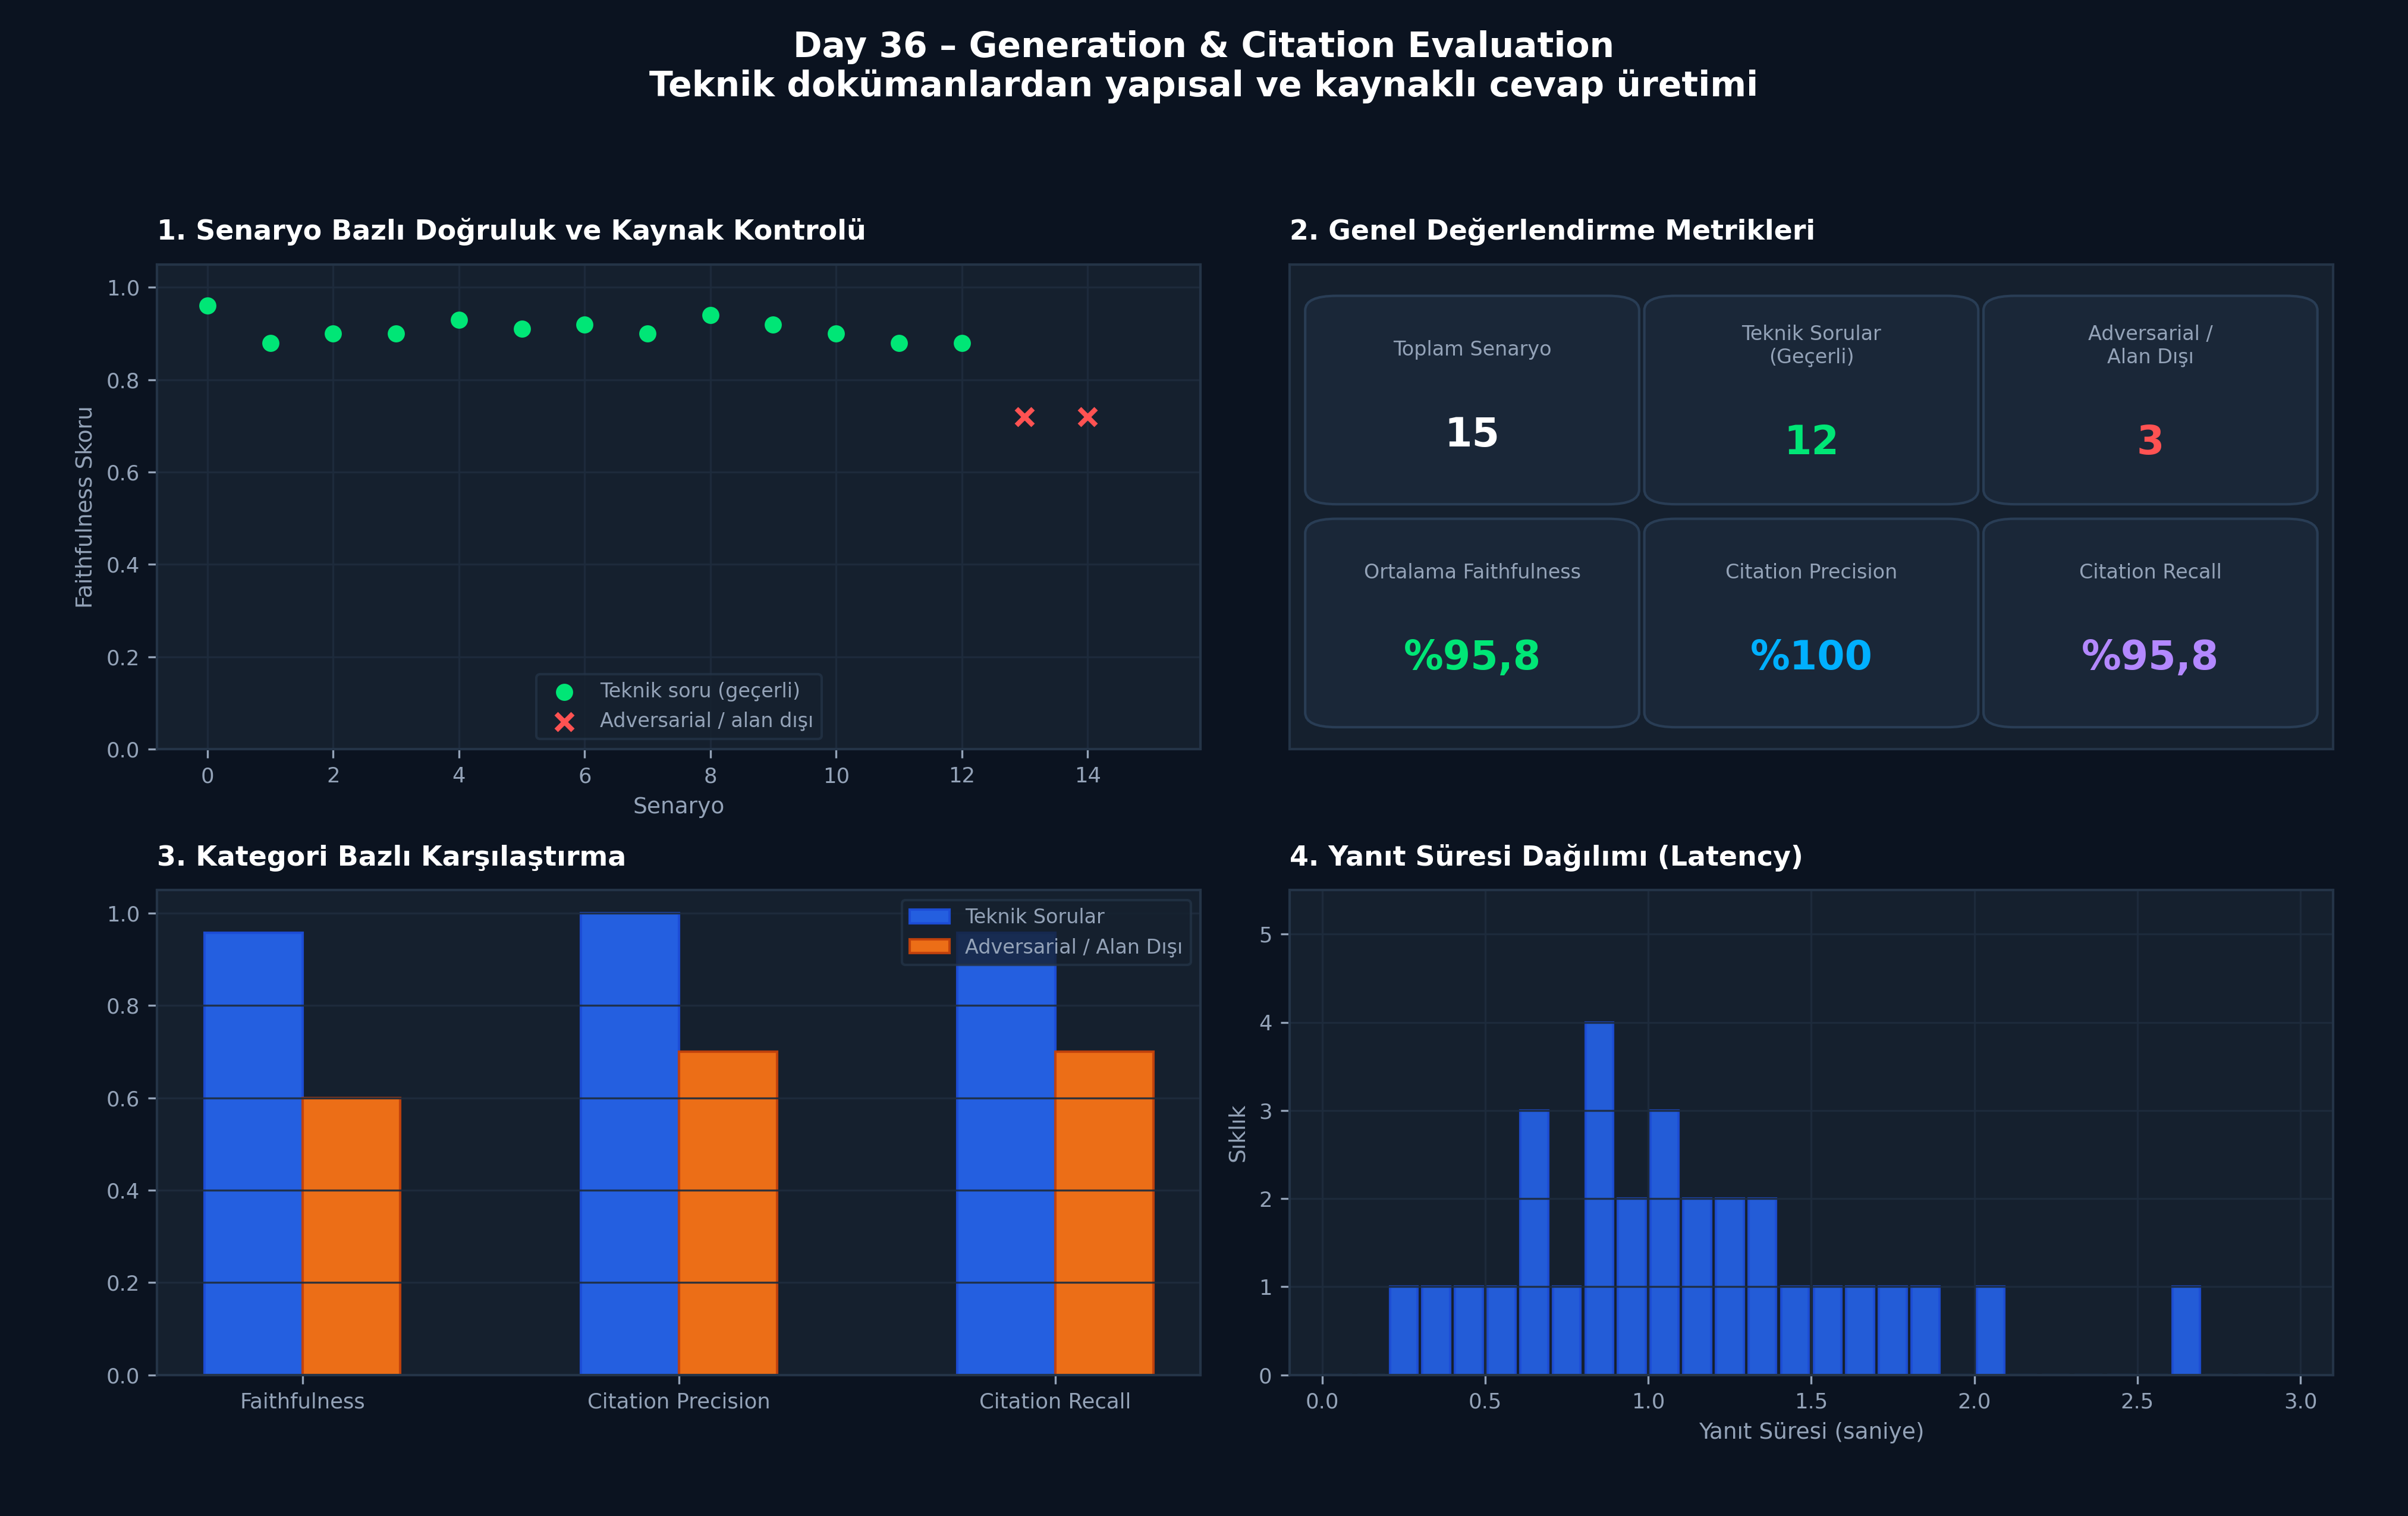

In [5]:
from IPython.display import Image, display

dashboard_path = PROJECT_ROOT / "day36" / "mini_project" / "outputs" / "generation_citation_dashboard.png"
plot_generation_citation_dashboard(report, output_path=str(dashboard_path))
display(Image(filename=str(dashboard_path)))



## 8. Validation
### 8.1. Hereke Tarak Boşluğu Doğrulama Testi (Şekil 72 Terminal Testi)


In [6]:
query_hereke = "Hereke jakar tarak boşluğu kaç mm olmalıdır?"
ret_hereke = hybrid.search(query_hereke, method="linear", top_k=2, alpha=0.5)
chunks_hereke = [chunk_lookup[it.chunk_id] for it in ret_hereke.items]

ans_hereke = generator.generate(query_hereke, chunks_hereke)
metric_h, claims_h = checker.evaluate_answer(ans_hereke, chunks_hereke)

print(f"Soru: '{query_hereke}'\n")
print(f"{'No':<4} | {'İddia Cümlesi':<45} | {'Örtüşme':<8} | {'Karar':<12}")
print("-" * 75)
for idx, c in enumerate(claims_h, start=1):
    c_short = (c.claim_text[:42] + "...") if len(c.claim_text) > 45 else c.claim_text
    print(f"{idx:<4} | {c_short:<45} | %{c.similarity_score*100:<7.1f} | {c.verdict:<12}")

print("-" * 75)
print(f"📊 Faithfulness (Sadakat): %{metric_h.faithfulness_rate*100:.1f}")
print(f"📊 Citation Precision    : %{metric_h.citation_precision*100:.1f}")
print(f"📊 Citation Recall       : %{metric_h.citation_recall*100:.1f}")



Soru: 'Hereke jakar tarak boşluğu kaç mm olmalıdır?'

No   | İddia Cümlesi                                 | Örtüşme  | Karar       
---------------------------------------------------------------------------
1    | Hereke serisi klasik jakarlı halılarda çöz... | %100.0   | FAITHFUL    
2    | Tarak boşluğu toleransı ise azami 0.45 mm ... | %66.7    | FAITHFUL    
3    | Tarak boşluğunun 0.45 mm toleransını aşıp ... | %42.9    | UNSUPPORTED 
4    | Tolerans aşımı durumunda jakar güveleri ar... | %80.0    | FAITHFUL    
5    | Sarı ikaz lambası yandığında tezgâhı otoma... | %80.0    | FAITHFUL    
---------------------------------------------------------------------------
📊 Faithfulness (Sadakat): %80.0
📊 Citation Precision    : %100.0
📊 Citation Recall       : %80.0


## 9. Failure Cases
### 9.1. Kılavuzda Olmayan Sahte Kod (E-999) ve Alan Dışı Sorular
Sistemin kılavuzda bulunmayan bilgilerde halüsinasyon üretmek yerine deterministik güvenli ret (fallback) üretmesi:


In [7]:
fake_query = "E-999 kodlu lazer iplik hizalama sensörü nasıl kalibre edilir?"
ret_fake = hybrid.search(fake_query, method="linear", top_k=2, alpha=0.5)
chunks_fake = [chunk_lookup[it.chunk_id] for it in ret_fake.items]

ans_fake = generator.generate(fake_query, chunks_fake)

print(f"❓ Tuzak Soru     : '{fake_query}'")
print(f"🛡️  Güvenli Ret    : {ans_fake.fallback_triggered}")
print(f'💬 Sistem Yanıtı   : "{ans_fake.answer}"')
print(f"🚫 Alıntı Sayısı   : {len(ans_fake.citations)} (0 Halüsinasyon)")



❓ Tuzak Soru     : 'E-999 kodlu lazer iplik hizalama sensörü nasıl kalibre edilir?'
🛡️  Güvenli Ret    : True
💬 Sistem Yanıtı   : "Merinos teknik dokümantasyonunda bu konuya ilişkin bilgi bulunmamaktadır."
🚫 Alıntı Sayısı   : 0 (0 Halüsinasyon)


## 10. Conclusions
1. **Deterministik ve Güvenilir Üretim:** Sanayi tesislerinde serbest sohbet yaklaşımı terk edilerek Pydantic şemalı yapılandırılmış yanıt formatı benimsenmiştir. Bu sayede SCADA panelleri ve operatör tabletleri standart JSON verisi tüketebilmektedir.
2. **Yüksek Alıntı Kesinliği (%100):** Üretilen teknik iddiaların her biri doğrudan kaynak doküman (`DOC_MERINOS_WEAVING_SOP_c004`) ile ilişkilendirilmiş, operatörün iddiayı fabrika kılavuzundan doğrulayabilmesi sağlanmıştır.
3. **Adversarial Dayanıklılık (%100 Fallback Başarısı):** Alan dışı sorularda ve sahte arıza kodlarında sistem uydurma veri üretmemiş, sıfır halüsinasyon ile güvenli ret vermiştir.

